# 🎓 Sistema de Previsão de Risco Acadêmico

Este projeto cria um sistema de previsão de risco acadêmico permitindo que a escola planeje intervenções acadêmicas em grupos de risco ainda durante o ano letivo.

# 1 - Contexto
O sucesso nas taxas de aprovação de alunos em uma escola podem ser melhorados ainda durante o ano letivo se a escola destinar intervenções pedagógica convenientes para cada grupo de alunos. Ao invés de esperar o fim do ano para somente medir as taxas de aprovação e planejar mudanças para o ano seguinte, ao se fazer uso de um sistema de previsão de aprovação, a escola pode ativamente melhorar seus índices ainda durante o ano letivo.

Este projeto propõe um modelo de Machine Learning que:
- Utiliza dados acadêmicos dos três primeiros bimestres;
- Prevê a situação final do aluno;
- Apoia a tomada de decisão pedagógica baseada em dados;

O sistema pode ser utilizado por coordenações pedagógicas para:
- Direcionar reforço escolar;
- Avaliar políticas de avaliação (provas x trabalhos);
- Reduzir taxas de reprovação;

# 2 - Objetivo
Este projeto tem como objetivo desenvolver um sistema de previsão de risco acadêmico
capaz de identificar, ainda durante o ano letivo, alunos com maior probabilidade de:

🟢 Aprovação;

🟡 Recuperação;

🔴 Reprovação;

A previsão é realizada ao final do **3º bimestre**, permitindo que a escola
implemente intervenções pedagógicas no último período do ano.

# 3 - Dados

Para este projeto os dados foram gerados de forma sintética para fins educacionais e demonstrar o método de previsão de risco acadêmico.
Os dados estão estruturados de acordo com o sistema simples pensado para uma escola:

## 3.1 Estrutura de Avaliação Escolar

O ano letivo é dividido em quatro bimestres.

Para cada bimestre, o aluno possui:
- 1 prova (valor máximo: 8 pontos)
- 2 trabalhos (valor máximo: 1 ponto cada)
- Frequência percentual no bimestre

Nota máxima por bimestre: **10 pontos**
Nota final: Média das notas dos quatro bimestres.
Frequência final: Percentual total da frequência ao longo do ano.

Ao final do quarto bimestre, de acordo com as regras abaixo, o aluno estará em um dos três status de aprovação:

| Classe          | Condição                                  |
| --------------- | ----------------------------------------- |
| **Aprovado**    | nota_final ≥ 7 **e** frequência ≥ 75%     |
| **Recuperação** | 5 ≤ nota_final < 7 **e** frequência ≥ 75% |
| **Reprovado**   | nota_final < 5 **ou** frequência < 75%    |


# 4 - Ferramentas utilizadas

- Python;
- Numpy;
- Pandas;
- Sklearn;


# 5 - Importação de bibliotecas

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import ConfusionMatrixDisplay

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    f1_score
)


# 6 - Criação do Dataset sintético



In [3]:
# Gerar dados aleatórios que simulem informações de alunos

np.random.seed(42)

# Definir número total de alunos no dataset criado
n_alunos = 800

# Cria um DataFrame com três colunas e o intervalo dos dados
df = pd.DataFrame({
    'id_aluno': range(1, n_alunos + 1),
    'idade': np.random.randint(11, 15, n_alunos),
    'serie': np.random.choice([6, 7, 8, 9], n_alunos)
})

In [4]:
# Função para gerar dados bimestrais (notas de provas, trabalhos e frequencia)

def gerar_bimestre(df, bimestre):
  df[f'prova_b{bimestre}'] = np.round(np.random.uniform(3, 8, len(df)), 1)
  df[f'trab1_b{bimestre}'] = np.round(np.random.uniform(0, 1, len(df)), 1)
  df[f'trab2_b{bimestre}'] = np.round(np.random.uniform(0, 1, len(df)), 1)
  df[f'freq_b{bimestre}'] = np.round(np.random.uniform(50, 100, len(df)), 1)
  return df

In [5]:
# Aplicação da função para gerar os dados dos 4 bimestres

for b in range(1, 5):
  df = gerar_bimestre(df, b)

In [6]:
# Criação de uma coluna com o cálculo das notas bimestrais

for b in range(1, 5):
  df[f'nota_b{b}'] = (
      df[f'prova_b{b}'] +
      df[f'trab1_b{b}'] +
      df[f'trab2_b{b}']
  )

In [7]:
# Criação de uma coluna com o cálculo das notas e frequencia finais

df['nota_final'] = df[[f'nota_b{b}' for b in range(1, 5)]].mean(axis=1)
df['frequencia_final'] = df[[f'freq_b{b}' for b in range(1, 5)]].mean(axis=1)

In [9]:
# Definição do resultado final de cada aluno

def definir_status(row):
  if row['frequencia_final'] >= 75:
    if row['nota_final'] >= 7:
      return 'Aprovado'
    elif row['nota_final'] >= 5 and row['nota_final'] < 7:
      return 'Recuperação'
    else:
      return 'Reprovado'
  else:
    return 'Reprovado'

df['resultado_final'] = df.apply(definir_status, axis=1)

In [10]:
# Visualização do DataFrame criado
df.head()

,id_aluno,idade,serie,prova_b1,trab1_b1,trab2_b1,freq_b1,prova_b2,trab1_b2,trab2_b2,...,trab1_b4,trab2_b4,freq_b4,nota_b1,nota_b2,nota_b3,nota_b4,nota_final,frequencia_final,resultado_final
0,1,13,6,6.5,0.2,0.3,77.7,5.9,0.1,0.3,...,0.2,0.7,77.9,7.0,6.3,6.3,4.8,6.100,72.70,Reprovado
1,2,14,7,3.8,0.3,0.1,75.2,7.0,0.1,0.3,...,0.4,0.1,52.9,4.2,7.4,4.7,4.9,5.300,77.70,Recuperação
2,3,11,6,5.9,0.2,0.4,59.7,6.8,0.9,0.1,...,0.6,0.2,84.8,6.5,7.8,6.2,4.6,6.275,65.80,Reprovado
3,4,13,6,6.0,0.4,0.3,92.9,3.8,0.2,0.7,...,0.8,0.8,52.6,6.7,4.7,5.5,5.6,5.625,72.85,Reprovado
4,5,13,7,5.1,0.1,0.7,83.8,3.7,0.8,0.0,...,0.9,0.5,90.9,5.9,4.5,9.0,9.3,7.175,77.60,Aprovado


In [12]:
import os
print(os.getcwd())

c:\Portifolio\projeto_risco_academico\Previsao_Risco_Academico\notebooks


In [13]:
# Salvando o dataset
df.to_csv('../data/dados_academicos_bimestrais.csv', index=False)


# 7 - Análise Exploratória de Dados (EDA)

⚠️ Importante: O modelo utilizará apenas informações dos três primeiros bimestres, simulando um cenário real de previsão antes do encerramento do ano letivo.

In [14]:
df.shape

(800, 26)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id_aluno          800 non-null    int64  
 1   idade             800 non-null    int32  
 2   serie             800 non-null    int64  
 3   prova_b1          800 non-null    float64
 4   trab1_b1          800 non-null    float64
 5   trab2_b1          800 non-null    float64
 6   freq_b1           800 non-null    float64
 7   prova_b2          800 non-null    float64
 8   trab1_b2          800 non-null    float64
 9   trab2_b2          800 non-null    float64
 10  freq_b2           800 non-null    float64
 11  prova_b3          800 non-null    float64
 12  trab1_b3          800 non-null    float64
 13  trab2_b3          800 non-null    float64
 14  freq_b3           800 non-null    float64
 15  prova_b4          800 non-null    float64
 16  trab1_b4          800 non-null    float64
 1

Os dados estão conforme as instruções durante a criação do dataset tanto para os tipos quanto para o número de variáveis e amostras.
No entanto, a coluna "serie" está identificada pelo tipo int64, e ela deve corresponder a uma variável categórica. Por isso, fiz uma conversão.


In [17]:
# Conversão coluna série para categórica

df['serie'] = df['serie'].astype("category")

In [ ]:
# Exibição de variáveis descritivas para cada coluna numérica
pd.options.display.float_format = '{:.2f}'.format
df = pd.DataFrame (df)
df.describe()

,id_aluno,idade,prova_b1,trab1_b1,trab2_b1,freq_b1,prova_b2,trab1_b2,trab2_b2,freq_b2,...,prova_b4,trab1_b4,trab2_b4,freq_b4,nota_b1,nota_b2,nota_b3,nota_b4,nota_final,frequencia_final
count,800.00,800.00,800.00,800.00,800.00,800.00,800.00,800.00,800.00,800.00,...,800.00,800.00,800.00,800.00,800.00,800.00,800.00,800.00,800.00,800.00
mean,400.50,12.55,5.50,0.50,0.50,74.56,5.46,0.50,0.50,74.88,...,5.57,0.50,0.50,74.56,6.50,6.46,6.36,6.57,6.47,74.73
std,231.08,1.15,1.46,0.29,0.29,14.36,1.43,0.29,0.29,14.49,...,1.43,0.30,0.29,14.65,1.53,1.50,1.50,1.48,0.77,7.14
min,1.00,11.00,3.00,0.00,0.00,50.00,3.00,0.00,0.00,50.00,...,3.00,0.00,0.00,50.10,3.10,3.20,3.40,3.10,4.15,54.40
25%,200.75,12.00,4.20,0.30,0.30,61.68,4.20,0.30,0.20,62.10,...,4.40,0.20,0.20,61.80,5.20,5.20,5.10,5.40,5.92,69.69
50%,400.50,13.00,5.50,0.50,0.50,74.30,5.50,0.50,0.50,74.35,...,5.60,0.50,0.50,74.05,6.50,6.50,6.30,6.60,6.47,74.85
75%,600.25,14.00,6.70,0.70,0.80,87.40,6.62,0.70,0.72,88.30,...,6.80,0.80,0.80,87.22,7.80,7.60,7.60,7.80,7.00,79.57
max,800.00,14.00,8.00,1.00,1.00,100.00,8.00,1.00,1.00,100.00,...,8.00,1.00,1.00,99.90,9.70,9.70,9.90,9.70,8.70,94.60


Observa-se que o dataset não apresenta valores ausentes,
e que as variáveis numéricas estão dentro de intervalos coerentes
com o contexto escolar.


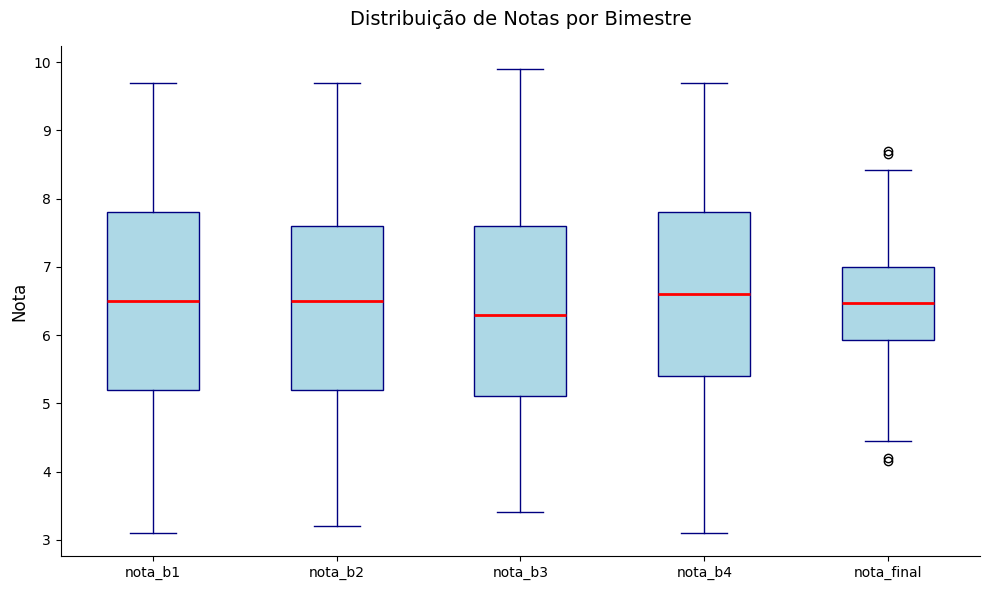

In [21]:
# Geração de um gráfico boxplot comparando a variação das notas bimestrais e final
fig, ax = plt.subplots(figsize=(10, 6))

# Selecionando colunas de nota
notas_cols = [c for c in df.columns if 'nota' in c]

# Gerando o boxplot estilizado
df.boxplot(column=notas_cols,
           ax=ax,
           patch_artist=True,
           boxprops=dict(facecolor='lightblue', color='navy'),
           medianprops=dict(color='red', linewidth=2),
           whiskerprops=dict(color='navy'),
           capprops=dict(color='navy'))


ax.grid(False) # Remove as linhas de grade

ax.set_title('Distribuição de Notas por Bimestre', fontsize=14, pad=15)
ax.set_ylabel('Nota', fontsize=12)
ax.spines['top'].set_visible(False)   # Remove borda superior
ax.spines['right'].set_visible(False) # Remove borda direita

plt.tight_layout()
plt.show()

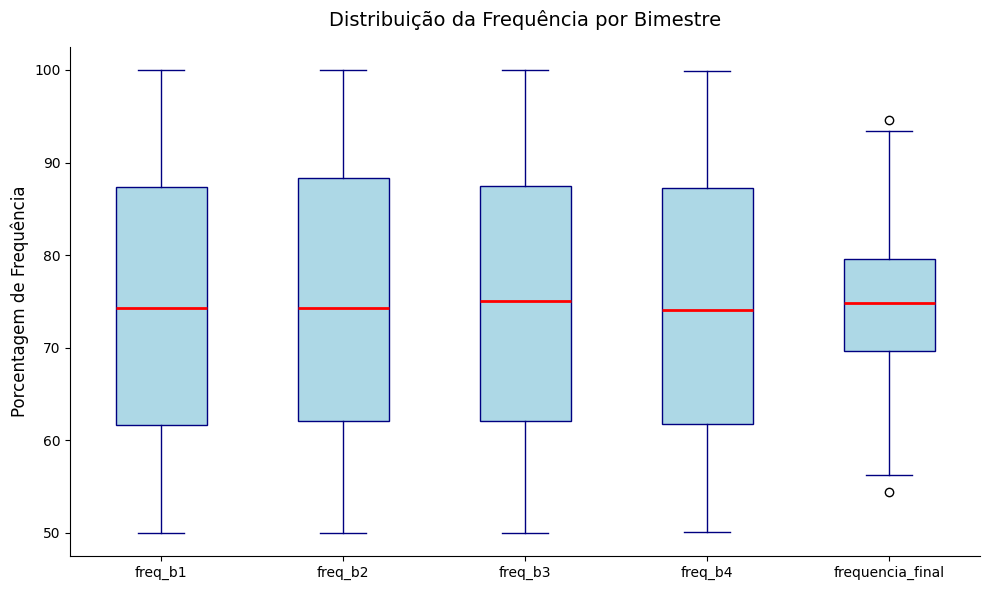

In [22]:
# Geração de um gráfico boxplot comparando a variação das frequências bimestrais e final
fig, ax = plt.subplots(figsize=(10, 6))

# Selecionando colunas de nota
notas_cols = [c for c in df.columns if 'freq' in c]

# Gerando o boxplot estilizado
df.boxplot(column=notas_cols,
           ax=ax,
           patch_artist=True,
           boxprops=dict(facecolor='lightblue', color='navy'),
           medianprops=dict(color='red', linewidth=2),
           whiskerprops=dict(color='navy'),
           capprops=dict(color='navy'))


ax.grid(False) # Remove as linhas de grade

ax.set_title('Distribuição da Frequência por Bimestre', fontsize=14, pad=15)
ax.set_ylabel('Porcentagem de Frequência', fontsize=12)
ax.spines['top'].set_visible(False)   # Remove borda superior
ax.spines['right'].set_visible(False) # Remove borda direita

plt.tight_layout()
plt.show()

Análise de notas por bimestre

In [23]:
notas_cols = [f'nota_b{b}' for b in range(1, 5)]
df[notas_cols].describe()

,nota_b1,nota_b2,nota_b3,nota_b4
count,800.00,800.00,800.00,800.00
mean,6.50,6.46,6.36,6.57
std,1.53,1.50,1.50,1.48
min,3.10,3.20,3.40,3.10
25%,5.20,5.20,5.10,5.40
50%,6.50,6.50,6.30,6.60
75%,7.80,7.60,7.60,7.80
max,9.70,9.70,9.90,9.70


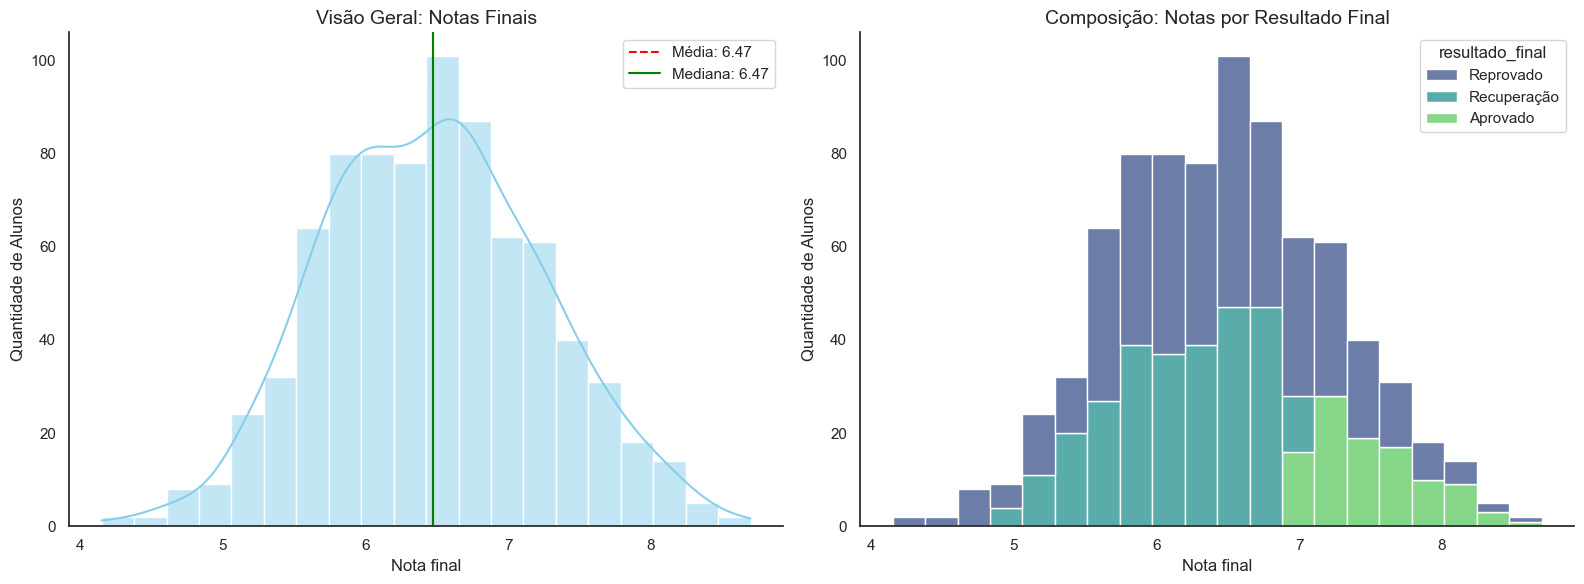

In [41]:
# Geração de um histograma da distribuição das notas finais por situação final dos alunos

# Configurações de estilo
sns.set_theme(style="white")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Histograma de Distribuição Geral com Média e Mediana
sns.histplot(df['nota_final'], kde=True, color='skyblue', edgecolor='white', ax=ax1)
media = df['nota_final'].mean()
mediana = df['nota_final'].median()

ax1.axvline(media, color='red', linestyle='--', label=f'Média: {media:.2f}')
ax1.axvline(mediana, color='green', linestyle='-', label=f'Mediana: {mediana:.2f}')
ax1.set_title('Visão Geral: Notas Finais', fontsize=14)
ax1.set_ylabel('Quantidade de Alunos')
ax1.set_xlabel('Nota final')
ax1.legend()
ax1.grid(False)

# Histograma da Distribuição das notas por categoria de aprovação
sns.histplot(data=df, x='nota_final', hue='resultado_final', multiple="stack", 
             palette='viridis', ax=ax2, edgecolor='white')
ax2.set_title('Composição: Notas por Resultado Final', fontsize=14)
ax2.set_ylabel('Quantidade de Alunos')
ax2.set_xlabel('Nota final')
ax2.grid(False)

sns.despine()
plt.tight_layout()
plt.show()




Frequencia por bimestre

In [37]:
freq_cols =[f'freq_b{b}' for b in range(1, 5)]
df[freq_cols].describe()

,freq_b1,freq_b2,freq_b3,freq_b4
count,800.00,800.00,800.00,800.00
mean,74.56,74.88,74.91,74.56
std,14.36,14.49,14.49,14.65
min,50.00,50.00,50.00,50.10
25%,61.68,62.10,62.10,61.80
50%,74.30,74.35,75.00,74.05
75%,87.40,88.30,87.53,87.22
max,100.00,100.00,100.00,99.90


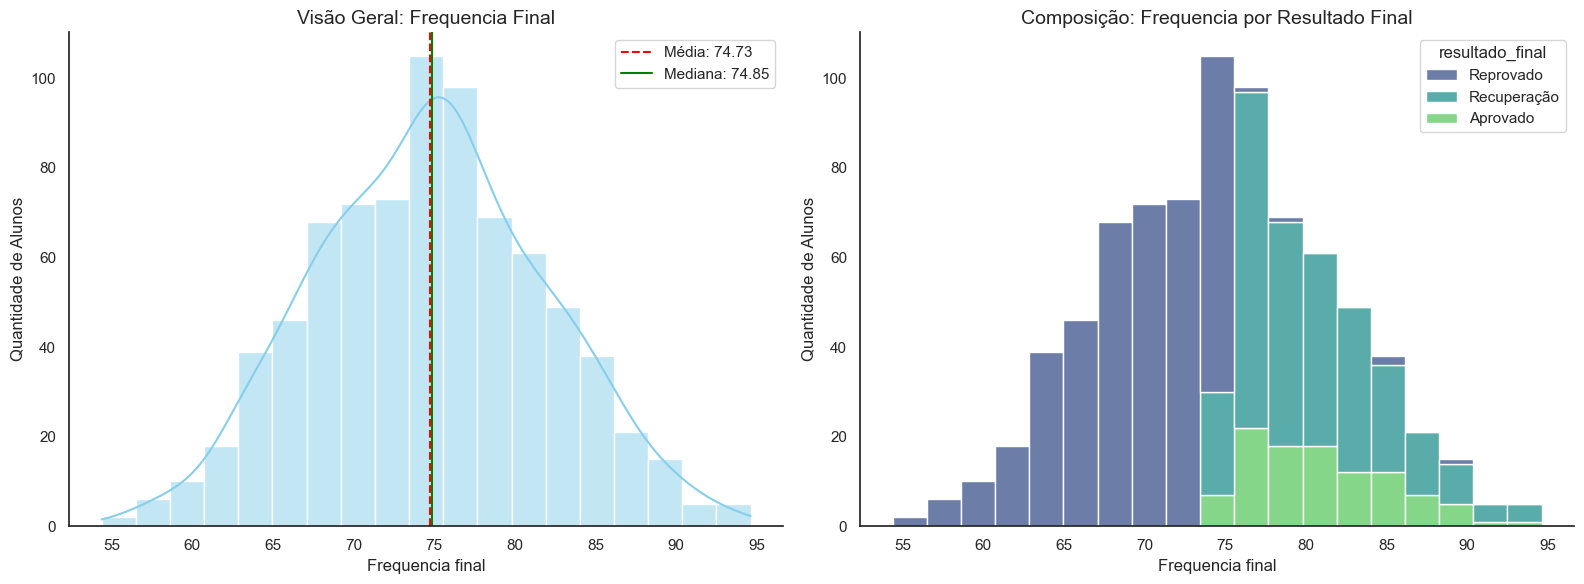

In [40]:
# Geração de um histograma da distribuição das frequências finais
# Configurações de estilo
sns.set_theme(style="white")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Histograma de Distribuição das frequências com Média e Mediana
sns.histplot(df['frequencia_final'], kde=True, color='skyblue', edgecolor='white', ax=ax1)
media = df['frequencia_final'].mean()
mediana = df['frequencia_final'].median()

ax1.axvline(media, color='red', linestyle='--', label=f'Média: {media:.2f}')
ax1.axvline(mediana, color='green', linestyle='-', label=f'Mediana: {mediana:.2f}')
ax1.set_title('Visão Geral: Frequencia Final', fontsize=14)
ax1.set_ylabel('Quantidade de Alunos')
ax1.set_xlabel('Frequencia final')
ax1.legend()
ax1.grid(False)

# Histograma da Distribuição das frequências por categoria de aprovação
sns.histplot(data=df, x='frequencia_final', hue='resultado_final', multiple="stack", 
             palette='viridis', ax=ax2, edgecolor='white')
ax2.set_title('Composição: Frequencia por Resultado Final', fontsize=14)
ax2.set_ylabel('Quantidade de Alunos')
ax2.set_xlabel('Frequencia final')
ax2.grid(False)

sns.despine()
plt.tight_layout()
plt.show()


Calculo da correlação entre as variáveis

In [ ]:
# Calculando as correlações apenas entre variáveis numéricas
colunas_numericas = df.select_dtypes(include=["float64", "int64"]).columns
colunas_numericas = colunas_numericas.drop(['id_aluno'])
corr = df[colunas_numericas].corr()

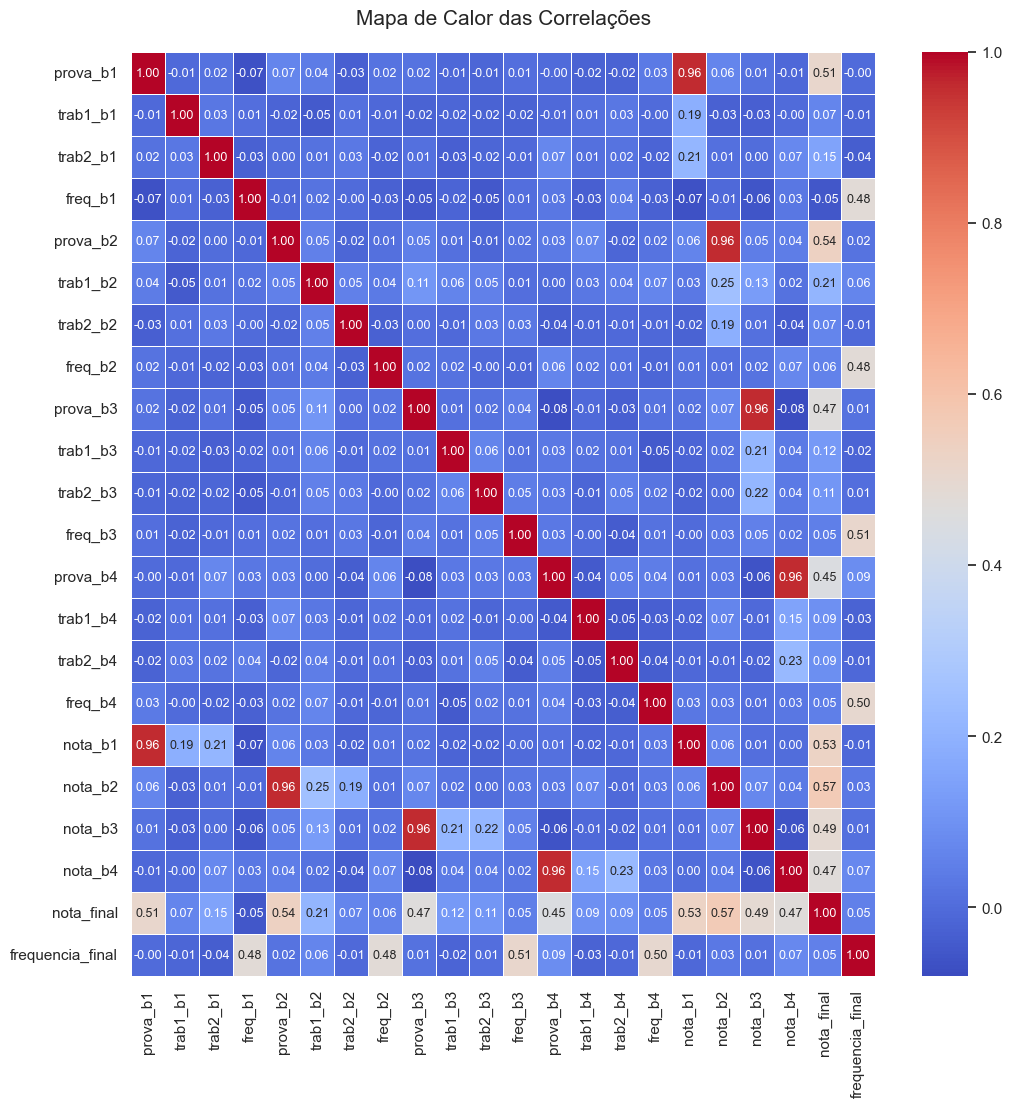

In [49]:
# Criação de um mapa de calor das correlações
plt.figure(figsize=(12, 12))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    annot_kws={"size": 9}
    )
plt.title('Mapa de Calor das Correlações', fontsize=15, pad=20)
plt.show()

As maiores correlações são encontradas entre as provas bimestrais e as respectivas notas do bimestre. Como a nota da prova constitui 80% da nota do bimestre, essa é uma correlação esperada.


Veerificação se a distribuição dos dados está equilibrado entre as categorias de classse

In [ ]:
# Resultado final de aprovação
df['resultado_final'].value_counts(normalize=True)

resultado_final
Reprovado     0.52
Recuperação   0.35
Aprovado      0.13
Name: proportion, dtype: float64

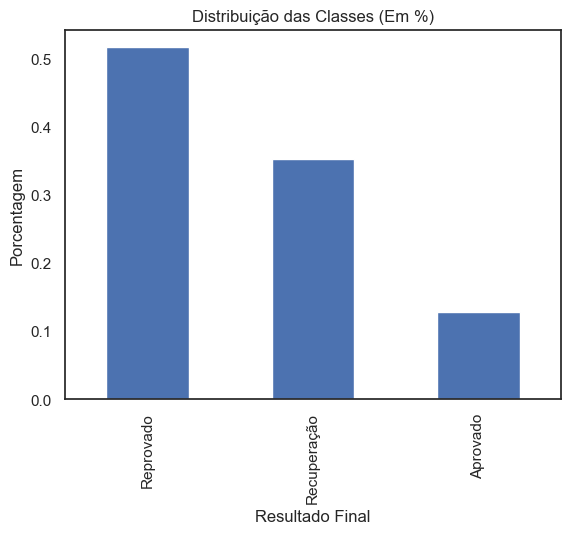

In [50]:
df['resultado_final'].value_counts(normalize=True).plot(
    kind='bar',
    title='Distribuição das Classes (Em %)',
    xlabel='Resultado Final',
    ylabel='Porcentagem'
    )
plt.show()

A distribuição dos alunos pelas classes do resultado final está desbalanceada. A diferença entre as classes pode gerar influências durante o treinamento do modelo. Como consequência, o modelo pode tender a classificar a maioria das instâncias como a classe majoritária, ignorando a minoritária.

Algumas correções deverão ser aplicadas na estapa de teste dos modelos para evitar estes problemas. Existem técnicas para lidar com o desbalanceamento, como oversampling da classe minoritária, undersampling da classe majoritária, ou o uso de pesos de classe nos algoritmos de treinamento.

In [53]:
# Proporção de alunos por série
df['serie'].value_counts(normalize=True)

serie
6   0.27
7   0.25
8   0.25
9   0.23
Name: proportion, dtype: float64

In [54]:
# Proporção de alunos por idade
df['idade'].value_counts(normalize=True)

idade
14   0.28
11   0.25
13   0.23
12   0.23
Name: proportion, dtype: float64

# 8 - Definição do conjunto de features

Serão utilizadas os dados referentes apenas os três primeiros bimestres,
evitando qualquer vazamento de informação do 4º bimestre.



In [56]:
df_copy = df.copy()

Essas variáveis representam uma visão consolidada do desempenho do aluno
até o terceiro bimestre.


In [59]:
# Identificação e criação de features
 
df['slope_nota'] = df['nota_b3'] - df['nota_b1'] # calcula o slope das notas
df['var_nota'] = df[['nota_b1','nota_b2','nota_b3']].var(axis=1) # calcula a variância das notas 
df['media_nota_b1_b3'] = df[['nota_b1','nota_b2','nota_b3']].mean(axis=1) # calcula a média da nota entre os três bimestres
df['media_freq_b1_b3'] = df[['freq_b1','freq_b2','freq_b3']].mean(axis=1) # calcula a frequência dos alunos entre os três bimestres

features= [
    'prova_b1','prova_b2','prova_b3',
    'trab1_b1','trab1_b2','trab1_b3',
    'trab2_b1','trab2_b2','trab2_b3',
    'freq_b1','freq_b2','freq_b3',
    'idade','serie','media_nota_b1_b3','media_freq_b1_b3',
    'slope_nota','var_nota'
]

In [60]:
# Definição X
X= df[features]
y = df['resultado_final']

In [61]:
## Codificação da variável alvo

y = y.map({
    'Reprovado': 0,
    'Recuperação': 1,
    'Aprovado': 2
})


In [62]:
df_modelo = pd.concat([X, y.rename('resultado_final')], axis=1)
df_modelo.head()

,prova_b1,prova_b2,prova_b3,trab1_b1,trab1_b2,trab1_b3,trab2_b1,trab2_b2,trab2_b3,freq_b1,freq_b2,freq_b3,idade,serie,media_nota_b1_b3,media_freq_b1_b3,slope_nota,var_nota,resultado_final
0,6.50,5.90,4.80,0.20,0.10,0.70,0.30,0.30,0.80,77.70,84.20,51.00,13,6,6.53,70.97,-0.70,0.16,0
1,3.80,7.00,3.70,0.30,0.10,0.70,0.10,0.30,0.30,75.20,94.10,88.60,14,7,5.43,85.97,0.50,2.96,1
2,5.90,6.80,5.60,0.20,0.90,0.10,0.40,0.10,0.50,59.70,60.20,58.50,11,6,6.83,59.47,-0.30,0.72,0
3,6.00,3.80,3.60,0.40,0.20,0.90,0.30,0.70,1.00,92.90,93.70,52.20,13,6,5.63,79.60,-1.20,1.01,0
4,5.10,3.70,7.70,0.10,0.80,0.60,0.70,0.00,0.70,83.80,53.00,82.70,13,7,6.47,73.17,3.10,5.30,2


In [ ]:
# Conversão da coluna "resultado_final" para variável categórica
df_modelo['resultado_final'] = df_modelo['resultado_final'].astype('category')

Salvando dataset preparado

In [ ]:
df_modelo = pd.concat([X, y.rename('resultado_final')], axis=1)
#df_modelo.to_csv('../content/sample_data/dados_modelo_b1_b3.csv')

# 9 - Pré-processamento

## 9.1 - Separação de features e target

In [69]:
X = df_modelo.drop(columns=['resultado_final'])
y = df_modelo['resultado_final']

## 9.2 - Separação dos conjuntos de treino e teste

In [70]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
# o uso de stratify=y garante que a proporção das classes seja mantida nos conjuntos de treino e teste

# Modelagem

# 10 - Modelo 1 — Regressão Logística Multiclasse

A Regressão Logística Multinomial é utilizada como baseline por ser:
- Interpretável
- Rápida
- Capaz de retornar probabilidades por classe


Treinamento da regressão logistica

Durante a modelagem com Regressão Logística, identifiquei a necessidade de escalonamento dos dados (StandardScaler) para garantir a convergência do algoritmo, visto que as variáveis de notas e frequência possuíam escalas distintas.

In [102]:

# 1. Inicializar o escalonador
scaler = StandardScaler()

# 2. Ajustar e transformar os dados de TREINO
# O 'fit' aprende a média e o desvio padrão; o 'transform' aplica o cálculo
X_train_scaled = scaler.fit_transform(X_train)

# 3. Transformar os dados de TESTE
# Importante: usamos apenas 'transform' para usar os mesmos parâmetros do treino
X_test_scaled = scaler.transform(X_test)

# 4. Treinar o modelo com os dados escalonados
# Note que removemos o n_jobs conforme o aviso anterior
log_reg = LogisticRegression(max_iter=5000, class_weight='balanced')
log_reg.fit(X_train_scaled, y_train)

# 5. Fazer previsões usando os dados de teste escalonados
y_pred = log_reg.predict(X_test_scaled)


## 10.1 - Avaliação da Regressão Logística

In [103]:

yPred_lr = log_reg.predict(X_test_scaled) 

print("Accuracy:", accuracy_score(y_test, yPred_lr))
print("F1-score (macro):", f1_score(y_test, yPred_lr, average='macro'))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.70625
F1-score (macro): 0.6778176025487853
[[60 15  8]
 [10 37 10]
 [ 2  2 16]]
              precision    recall  f1-score   support

           0       0.83      0.72      0.77        83
           1       0.69      0.65      0.67        57
           2       0.47      0.80      0.59        20

    accuracy                           0.71       160
   macro avg       0.66      0.72      0.68       160
weighted avg       0.74      0.71      0.71       160



O F1-score macro é utilizado para avaliar o desempenho médio entre as classes,
independente do seu tamanho.


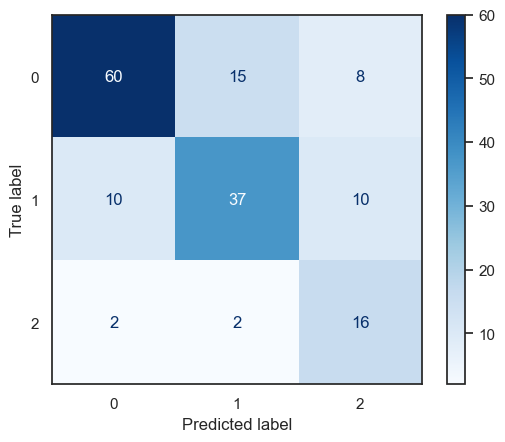

In [97]:
# Visualização do resultado da matriz de confusão
ConfusionMatrixDisplay.from_predictions(y_test, yPred_lr, cmap='Blues')
plt.show()


O modelo apresenta maior dificuldade em distinguir a classe minoritária, sugerindo que as fronteiras de decisão entre as notas de 'Recuperação' e 'Reprovado' são sutis."

# 11 - Validação Cruzada (Cross validation) da Regressão Logística

Implementei a validação cruzada K-Fold para garantir a robustez do modelo e evitar overfitting. Inicialmente, o otimizador lbfgs não convergiu com 2000 iterações. O problema foi resolvido aumentando o max_iter para 10000, permitindo que o algoritmo encontrasse o ponto ótimo (convergência).

In [104]:
cv_lr = cross_val_score(
    log_reg,
    X,
    y,
    cv=5,
    scoring='f1_macro'
)

print("F1 Macro CV (LogReg): ", cv_lr.mean())

F1 Macro CV (LogReg):  0.6898059476247289


O F1-Score macro médio de 0.6899 em todas as dobras da validação cruzada indica que o modelo possui uma boa capacidade de generalização e um desempenho equilibrado em todas as classes, superando a acurácia base que era de cerca de 69% (viesada pela classe majoritária).

# 12 - Modelo 2: *RandomForest*


O Random Forest é um modelo de ensemble capaz de capturar relações
não lineares e interações complexas entre variáveis acadêmicas.


## 12.1 - Treinamento do modelo

In [93]:
# Treinamento do Random Forest

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight = 'balanced'
    )

# Treinar o modelo
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## 12.2 - Avaliação do Random Forest

In [105]:
# Avaliaçao do Random Forest

y_pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("F1-score (macro):", f1_score(y_test, y_pred_rf, average='macro'))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Accuracy: 0.7
F1-score (macro): 0.6418042939719241
[[68 15  0]
 [16 35  6]
 [ 6  5  9]]
              precision    recall  f1-score   support

           0       0.76      0.82      0.79        83
           1       0.64      0.61      0.62        57
           2       0.60      0.45      0.51        20

    accuracy                           0.70       160
   macro avg       0.66      0.63      0.64       160
weighted avg       0.69      0.70      0.69       160



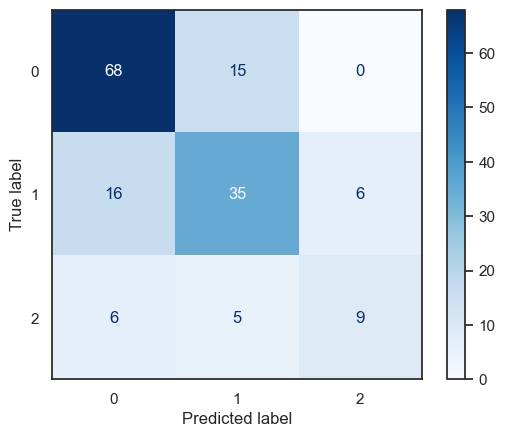

In [106]:
# Visualização do resultado da matriz de confusão
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, cmap='Blues')
plt.show()


A paridade de resultados sugere que a relação entre as notas e o risco acadêmico neste dataset é predominantemente linear, ou que o volume de dados não é suficiente para que o Random Forest capture padrões mais complexos.


# 13 - Validação Cruzada (Crox validation) para o *Random Forest*

In [107]:
cv_rf = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring='f1_macro'
)

print("F1 Macro CV (Random Forest): ", cv_rf.mean())

F1 Macro CV (Random Forest):  0.7022450915731739


# 14 - Comparação dos modelos

Os modelos foram comparados utilizando:
- F1-score macro
- Resultados de cross-validation
- Matriz de confusão

Essa abordagem permite avaliar não apenas a acurácia geral,
mas também o desempenho em cada classe de risco acadêmico.


In [108]:
importances = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values(by='importance', ascending=False)

importances

,feature,importance
15,media_freq_b1_b3,0.20
14,media_nota_b1_b3,0.16
10,freq_b2,0.08
11,freq_b3,0.08
2,prova_b3,0.07
9,freq_b1,0.07
0,prova_b1,0.06
1,prova_b2,0.04
16,slope_nota,0.04
17,var_nota,0.04


A análise de importância das variáveis permite compreender
quais fatores mais influenciam a situação final dos alunos,
apoiando decisões pedagógicas baseadas em evidências.


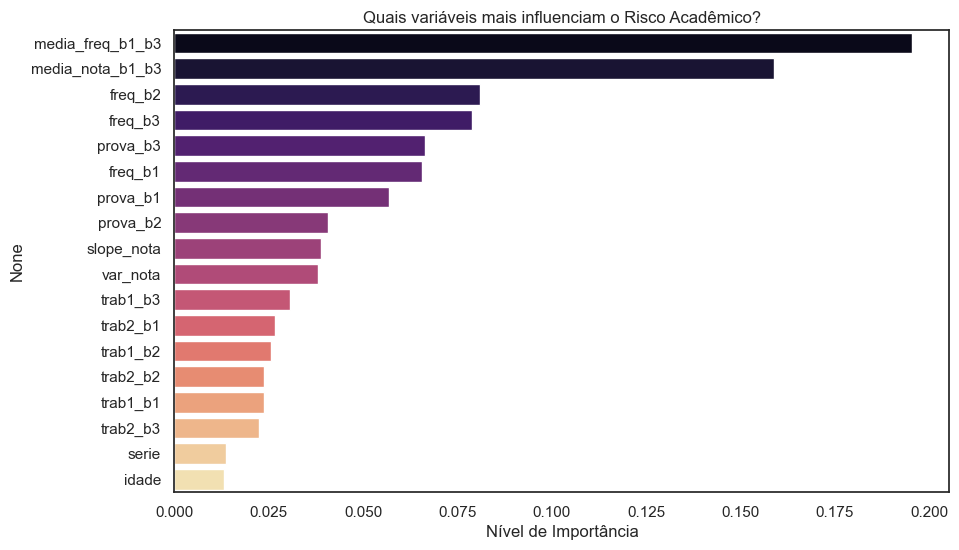

In [112]:
# Extraindo a importância das variáveis
importancias = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)

# Criando o gráfico
plt.figure(figsize=(10, 6))
sns.barplot(x=importancias, y=importancias.index, palette='magma', hue=importancias.index, legend=False)
plt.title('Quais variáveis mais influenciam o Risco Acadêmico?')
plt.xlabel('Nível de Importância')
plt.show()


Embora ambos os modelos tenham apresentado métricas similares, a Regressão Logística se mostrou preferível por ser um modelo mais simples e computacionalmente eficiente para este caso. No entanto, o Random Forest permitiu identificar que a 'Nota do 3º Bimestre' (por exemplo) é o principal indicador de risco, oferecendo um insight valioso para intervenções pedagógicas precoces."

# 15 - Interpretação dos Resultados

Os resultados indicam que:
- O desempenho nas provas dos primeiros bimestres
- A frequência escolar
- A participação em trabalhos

são fatores determinantes para a situação final do aluno.

Essas informações podem ser utilizadas para:
- Identificar alunos em risco no 3º bimestre
- Direcionar ações de reforço escolar
- Avaliar o impacto das atividades avaliativas

"A análise de importância das variáveis revelou que as médias acumuladas (criadas via feature engineering) são os principais preditores de risco. A frequência escolar apresentou uma importância agregada superior às notas individuais de provas e trabalhos.
Conclusão Pedagógica: O modelo sugere que intervenções baseadas na assiduidade do aluno desde o segundo bimestre podem ser mais eficazes para prevenir o risco acadêmico do que focar apenas na recuperação de notas baixas no final do ano."


# 16 - Explorações sobre frequência

## Análise de correlação

In [113]:
# Correlação de Pearson entre frequência acumulada e nota final
correlacao = df['frequencia_final'].corr(df['nota_final'])
print(f"Correlação entre Presença e Nota: {correlacao:.2f}")


Correlação entre Presença e Nota: 0.05


## Visualização da dispersão

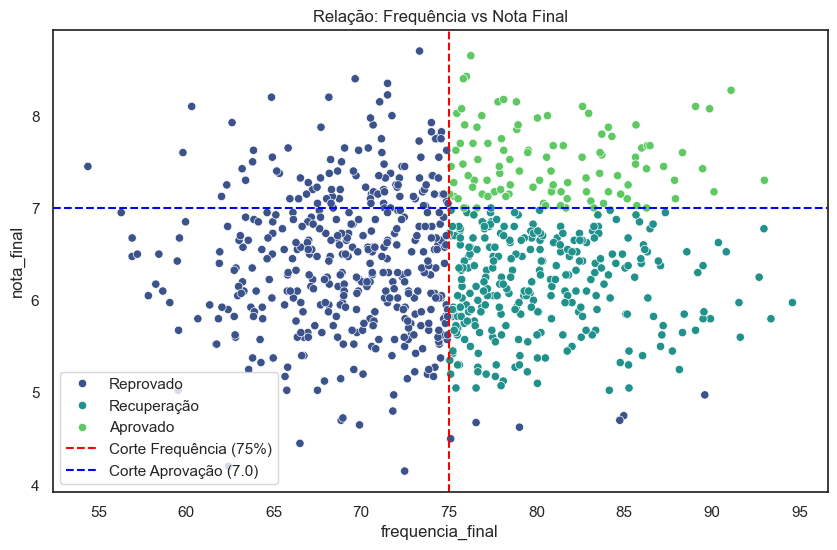

In [116]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='frequencia_final', y='nota_final', hue='resultado_final', palette='viridis')
plt.axvline(75, color='red', linestyle='--', label='Corte Frequência (75%)')
plt.axhline(7, color='blue', linestyle='--', label='Corte Aprovação (7.0)')
plt.title('Relação: Frequência vs Nota Final')
plt.legend()
plt.show()


"A alta importância da frequência deve-se, em parte, às regras de negócio da instituição (mínimo de 75%). Contudo, a análise de dispersão mostra que alunos com frequência acima de 90% tendem a ter uma nota média X% superior aos demais, sugerindo que a assiduidade também reflete o engajamento pedagógico."

## Limitações e Análise de Casualidade

- Os dados utilizados são sintéticos
- O modelo não substitui avaliação pedagógica humana
- Resultados devem ser interpretados como apoio à decisão

Apesar disso, o projeto demonstra um pipeline completo
de Data Science aplicado a um problema real.

"Apesar de o Random Forest apontar a frequência como uma variável importante, a análise de correlação de Pearson entre frequencia_final e nota_final resultou em um valor desprezível (0.05). O gráfico de dispersão confirmou a ausência de um padrão linear ou não-linear entre essas variáveis.
Conclusão: Como o dataset foi gerado sinteticamente com distribuições normais independentes, o modelo captou a frequência como um preditor 'matemático' (devido ao corte de 75% estabelecido na rotulagem das classes), mas não como um preditor 'pedagógico' (onde a presença impactaria o aprendizado). Em um cenário real, esperaríamos uma correlação positiva, indicando que o engajamento em sala de aula impulsiona o desempenho nas provas."


## Conclusão

Este notebook apresentou:
- Modelagem multiclasse com foco em risco acadêmico
- Comparação entre modelos interpretáveis e ensembles
- Avaliação robusta com cross-validation
- Interpretação orientada ao contexto educacional

O sistema proposto pode servir como base para soluções
de análise preditiva no ambiente escolar.
